In [97]:
import stats_models as mod
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep

In [98]:
config, path_file = mod.load_config("config.json", "analysis_paths.json")

yields_file = "/data/dcostach/diquark/"+path_file[config["process"]]+"/signal_yields/sig_bkg_D"+str(int(config["discriminator"]*1000))+".csv"
df_yields = pd.read_csv(yields_file)
uncrt_file = "/data/dcostach/diquark/"+path_file[config["process"]]+"/signal_yields/uncrt.csv"
df_uncrt = pd.read_csv(uncrt_file)

In [99]:
handlers = {
    ("cls", "asymptotic"): mod.run_cls_asymptotics,
    ("cls", "toybased"): lambda yld, unc: mod.run_cls_toybased(yld, unc, config["nToys"]),
    ("limits", "asymptotic"): mod.run_limits_asymptotics,
    ("limits", "toybased"): lambda yld, unc: mod.run_limits_toybased(yld, unc, config["nToys"]),
    ("pval", "asymptotic"): mod.run_pval_asymptotics,
    ("pval", "toybased"): lambda yld, unc: mod.run_pval_toybased(yld, unc, config["nToys"]),
}

key = (config["runType"], config["calcType"])
runner = handlers[key]

In [104]:
res = runner(df_yields.iloc[0].to_dict(), df_uncrt.iloc[0].to_dict())
print(type(res.observed))


Running asymptotic CLs computation for:
M_S: 7.0 TeV
Observed CLs (Median)         : 6.028809411226736e-06
Expected -1 Sigma             : 1.036145577655815e-07
Expected CLs (Median)         : 6.028809411226786e-06
Expected +1 Sigma             : 0.0002513127863831049
Done.


AttributeError: 'tuple' object has no attribute 'observed'

In [101]:
results = []

# for i in range(len(df_yields)):
#     yields_point = df_yields.iloc[i].to_dict()
#     uncrt_point = df_uncrt.iloc[i].to_dict()

#     type(runner(yields_point, uncrt_point))
#     # results.append(runner(yields_point, uncrt_point))

ValueError: x and y must have same first dimension, but have shapes (8,) and (0,)

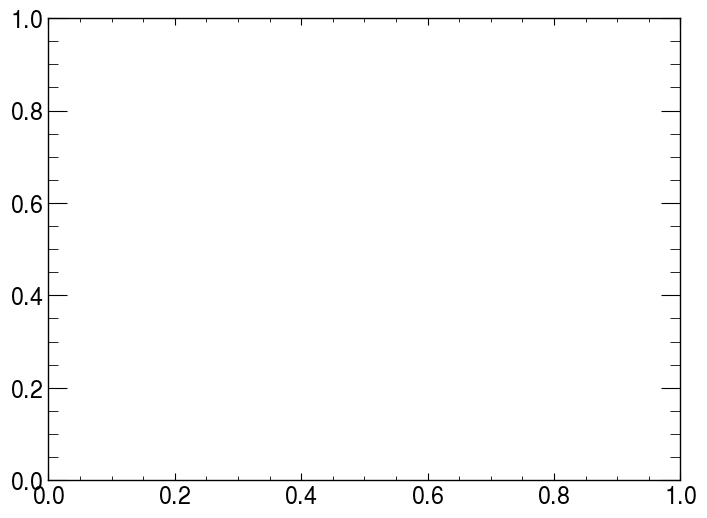

In [102]:
fig, ax = plt.subplots()

hep.style.use("ATLAS")

# m = df_yields['M_S'].to_numpy()
# signal = df_yields['SIG'].to_numpy()
# limit = np.asarray([res[2] for res in results])

# # Find the first place where signal yield and expected limit cross
# # and interpolate the crossing mass between the neighboring data points.
# diff = signal - limit
# cross_idx = None

# for i in range(len(diff) - 1):
#     if diff[i] == 0:
#         cross_idx = i
#         break
#     if diff[i] * diff[i + 1] < 0:
#         cross_idx = i
#         break

# if cross_idx is not None:
#     if diff[cross_idx] == 0:
#         x_cross = m[cross_idx]
#     else:
#         x_cross = m[cross_idx] - diff[cross_idx] * (m[cross_idx + 1] - m[cross_idx]) / (diff[cross_idx + 1] - diff[cross_idx])

#     ax.axvline(
#         x_cross,
#         color='red',
#         linestyle='--',
#         linewidth=1.5,
#         label=f'Crossing at {x_cross:.2f} TeV'
#     )

# ax.set_yscale('log')
# ax.plot(m, limit, color='k', marker='o', label='Expected Median')
# ax.plot(m, signal, color='k', marker='o', ls='--', label='Signal Yield')
# ax.legend()
# ax.set_xlim(m.min()-0.25, m.max()+0.25)
# ax.set_xlabel('$M_S$ [TeV]')
# ax.set_ylabel('Event counts')

ax.plot(df_yields['M_S'], [res[2] for res in results[1:]], color='black', label='Expected Median')
ax.fill_between(df_yields['M_S'], [res[1] for res in results[1:]], [res[3] for res in results], color='green', alpha=0.3, label='Expected ±1σ')
ax.fill_between(df_yields['M_S'], [res[0] for res in results[1:]], [res[4] for res in results], color='yellow', alpha=0.3, label='Expected ±2σ')
ax.hlines(0.05, xmin=df_yields['M_S'].min(), xmax=df_yields['M_S'].max(), color='red', linestyle='--', label='95% CL')

ax.legend()
hep.mpl_magic()
plt.show()